In [6]:
import torch,gc
from transformers import AutoTokenizer, AutoModelForCausalLM
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns



- How many cases have short correct answers? (DPO examples)
- Detailed breakdown of the data (columns, number of columns saving format )
- Run inference of model without token limit, how many tokens are generated per quesiton?
- What is the distribution of the shortes correct answer over questions in the case without target?

In [19]:
csv_dir = Path("../generated")
files = sorted(f for f in csv_dir.iterdir() if f.is_file() and f.name.startswith("generated_batch") and f.suffix == ".csv" )
df = pd.concat((pd.read_csv(fp) for fp in files), ignore_index=True)
print(df.shape)
df

(18880, 9)


,question_id,prompt,solution_col,generated_think_text,generated_text,target_think_tokens,generated_think_tokens,latency_sec,is_correct
0,0,"Let \[f(x) = \left\{\n\begin{array}{cl} ax+3, ...","For the piecewise function to be continuous, t...","Okay, so I have this piecewise function f(x) a...",<｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of...,100,359,249.723614,True
1,0,"Let \[f(x) = \left\{\n\begin{array}{cl} ax+3, ...","For the piecewise function to be continuous, t...","Okay, so I have this piecewise function f(x) a...",<｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of...,366,499,249.723614,True
2,0,"Let \[f(x) = \left\{\n\begin{array}{cl} ax+3, ...","For the piecewise function to be continuous, t...","Okay, so I have this piecewise function f(x) a...",<｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of...,633,524,249.723614,True
3,0,"Let \[f(x) = \left\{\n\begin{array}{cl} ax+3, ...","For the piecewise function to be continuous, t...","Okay, so I have this piecewise function f(x) a...",<｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of...,900,1152,249.723614,True
4,0,"Let \[f(x) = \left\{\n\begin{array}{cl} ax+3, ...","For the piecewise function to be continuous, t...","Okay, so I have this piecewise function f(x) d...",<｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of...,1166,1346,249.723614,True
...,...,...,...,...,...,...,...,...,...
18875,633,For what values of $z$ is $z^2-40z+340\le 4$? ...,We can simplify the inequality to $z^2-40z+336...,"Okay, so I have this inequality to solve: z² -...",<｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of...,366,501,304.172000,True
18876,633,For what values of $z$ is $z^2-40z+340\le 4$? ...,We can simplify the inequality to $z^2-40z+336...,"Okay, so I have this inequality to solve: z² -...",<｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of...,633,573,304.172000,True
18877,633,For what values of $z$ is $z^2-40z+340\le 4$? ...,We can simplify the inequality to $z^2-40z+336...,"Okay, so I have this inequality to solve: z² -...",<｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of...,900,323,304.172000,True
18878,633,For what values of $z$ is $z^2-40z+340\le 4$? ...,We can simplify the inequality to $z^2-40z+336...,"Okay, so I have this inequality to solve: z² -...",<｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of...,1166,481,304.172000,True


In [33]:
print(np.linspace(100, 2500, num=10, endpoint=True, dtype=int))
print(np.round(np.linspace(100, 1166, num=5, endpoint=True)).astype(int))

[ 100  366  633  900 1166 1433 1700 1966 2233 2500]
[ 100  366  633  900 1166]


In [73]:
print(df.shape)
correct = df[df["is_correct"]] 
correct.shape

(18880, 9)


(16785, 9)

(1888,)
(16785, 9)
The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.


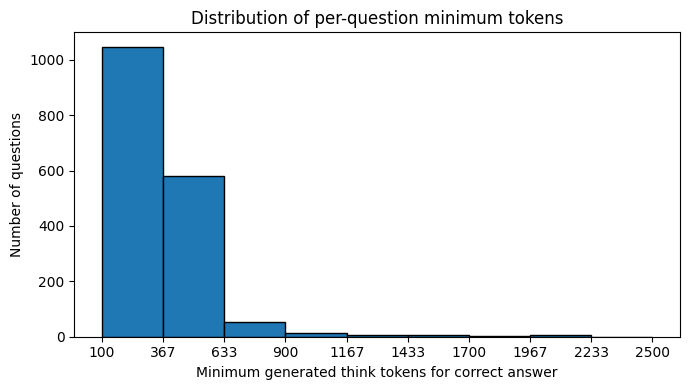

(1801,)


<Axes: xlabel='target_think_tokens', ylabel='Density'>

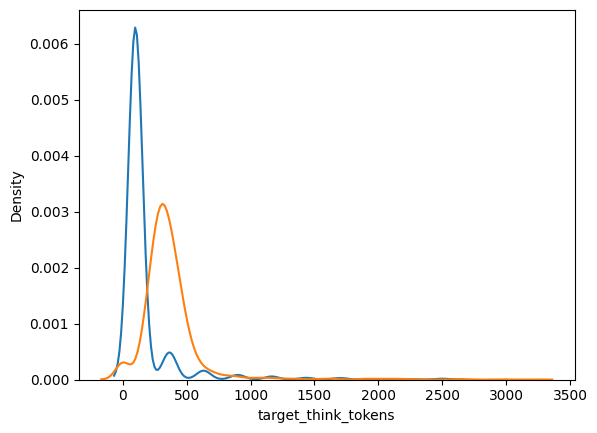

In [ ]:
tokens = np.round(np.linspace(100, 2500, num=10, endpoint=True)).astype(int)
print(df["question_id"].unique().shape)
# only keep correct rows
correct = df[df["is_correct"]]
print(correct.shape)
# compute min target per question
min_tokens = (correct.groupby("question_id")["generated_think_tokens"].min().sort_values())
plt.figure(figsize=(7, 4))
plt.hist(
    min_tokens,
    bins=np.append(tokens - 0.5, tokens[-1] + 0.5),  # center bins on each token
    edgecolor='black'
)
plt.xticks(tokens)
plt.xlabel("Minimum generated think tokens for correct answer")
plt.ylabel("Number of questions")
plt.title("Distribution of per-question minimum tokens")
plt.tight_layout()
plt.show()

print(min_tokens.shape)
min_tokens_target = (correct.groupby("question_id")["target_think_tokens"].min().sort_values())
fig, ax = plt.subplots()

sns.kdeplot(min_tokens_target, ax=ax)
sns.kdeplot(min_tokens, ax=ax)

In [67]:
num_correct = df['is_correct'].sum()
print(num_correct * 100 / df.shape[0])
df.groupby("question_id")["is_correct"].mean().describe()


88.90360169491525


count    1888.000000
mean        0.889036
std         0.251696
min         0.000000
25%         0.900000
50%         1.000000
75%         1.000000
max         1.000000
Name: is_correct, dtype: float64

In [11]:
incorrect_rows = df[df['is_correct'] == False]

incorrect_rows[["solution_col", "generated_think_text", "generated_text"]]
incorrect_rows.to_csv("incorrect.csv")

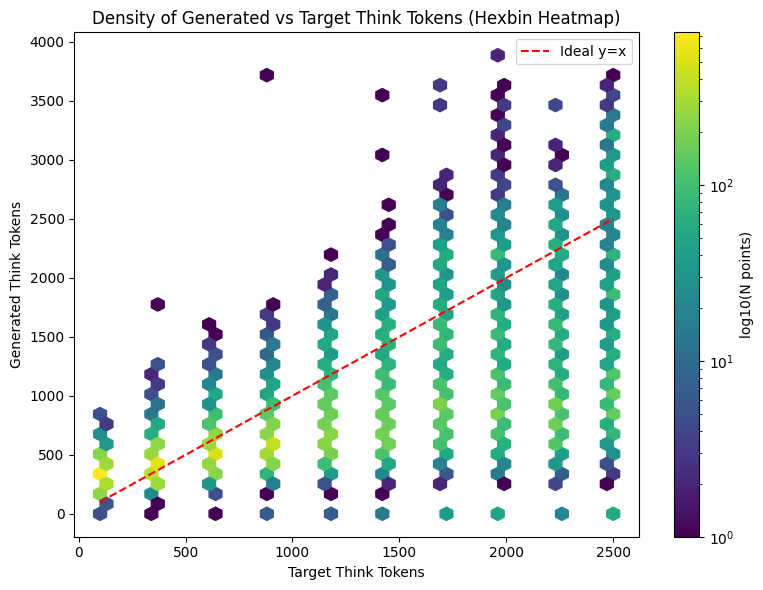

In [ ]:
plt.figure(figsize=(8,6))
hb = plt.hexbin(
    df["target_think_tokens"],
    df["generated_think_tokens"],
    gridsize=40,           # number of hexes along x-axis (adjust for resolution)
    cmap="viridis",
    bins="log"             # log color scale = better for uneven densities
)
plt.colorbar(hb, label="log10(N points)")
mn, mx = df["target_think_tokens"].min(), df["target_think_tokens"].max()
plt.plot([mn, mx], [mn, mx], "r--", label="Ideal y=x")
plt.xlabel("Target Think Tokens")
plt.ylabel("Generated Think Tokens")
plt.title("Density of Generated vs Target Think Tokens (Hexbin Heatmap)")
plt.legend()
plt.tight_layout()
plt.show()


In [2]:

model_path = "/scratch/s6019595/models/L1-Qwen-1.5B-Exact"
tok = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForCausalLM.from_pretrained(
    model_path, torch_dtype=torch.bfloat16, device_map="cuda"
)
model.eval()

prompt = "Solve 23×19. Think step by step."
tokens_per_sample = 2000

for bs in [1, 2, 4, 8]:
    print(f"\nBatch size {bs}")
    torch.cuda.reset_peak_memory_stats()
    inputs = tok([prompt]*bs, return_tensors="pt", padding=True, truncation=True).to("cuda")

    with torch.inference_mode():
        outputs = model(**inputs, use_cache=True)
        past = outputs.past_key_values
        next_token = torch.argmax(outputs.logits[:, -1, :], dim=-1)

        for step in range(tokens_per_sample):
            out = model(input_ids=next_token.unsqueeze(-1), past_key_values=past, use_cache=True)
            past = out.past_key_values
            next_token = torch.argmax(out.logits[:, -1, :], dim=-1)

            if step % 100 == 0:
                torch.cuda.synchronize()
                peak = torch.cuda.max_memory_allocated() / 1e9
                print(f"Step {step:4d}: {peak:6.2f} GB")

    final_peak = torch.cuda.max_memory_allocated() / 1e9
    print(f"Final peak for batch {bs}: {final_peak:.2f} GB")

    del inputs, out, outputs, past, next_token
    gc.collect()
    torch.cuda.empty_cache()


`torch_dtype` is deprecated! Use `dtype` instead!


ValueError: Using a `device_map`, `tp_plan`, `torch.device` context manager or setting `torch.set_default_device(device)` requires `accelerate`. You can install it with `pip install accelerate`

In [20]:
math_dataset_df = pd.read_parquet("hf://datasets/qwedsacf/competition_math/data/train-00000-of-00001-7320a6f3aba8ebd2.parquet")
math_dataset_df

,problem,level,type,solution
0,"Let \[f(x) = \left\{\n\begin{array}{cl} ax+3, ...",Level 5,Algebra,"For the piecewise function to be continuous, t..."
1,A rectangular band formation is a formation wi...,Level 5,Algebra,Let $x$ be the number of band members in each ...
2,What is the degree of the polynomial $(4 +5x^3...,Level 3,Algebra,This polynomial is not written in standard for...
3,Evaluate $\left\lceil3\left(6-\frac12\right)\r...,Level 3,Algebra,"Firstly, $3\left(6-\frac12\right)=18-1-\frac12..."
4,Sam is hired for a 20-day period. On days that...,Level 3,Algebra,Call $x$ the number of days Sam works and $y$ ...
...,...,...,...,...
12495,If $\sin x + \cos x = \frac{1}{5}$ and $0 < x ...,Level 5,Precalculus,"From the given equation, $\cos x = \frac{1}{5}..."
12496,The matrix for projecting onto a certain plane...,Level 5,Precalculus,Since $\begin{pmatrix} a \\ b \\ c \end{pmatri...
12497,"Let $\mathbf{a},$ $\mathbf{b},$ and $\mathbf{c...",Level 4,Precalculus,Since $\mathbf{a} + \mathbf{b} + \mathbf{c} = ...
12498,Find the smallest positive integer solution to...,Level 5,Precalculus,"By the tangent addition formula,\n\begin{align..."


In [3]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
model_path = "/scratch/s6019595/models/L1-Qwen-1.5B-Exact"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)
model_LCPO = AutoModelForCausalLM.from_pretrained(
    model_path,
    torch_dtype=torch.bfloat16,
    device_map=device
)
tokenizer = AutoTokenizer.from_pretrained(model_path)


/home4/s6019595/.llmvenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`torch_dtype` is deprecated! Use `dtype` instead!


cuda


Loading checkpoint shards: 100%|██████████| 2/2 [03:09<00:00, 94.54s/it] 


In [ ]:
vocab = tokenizer.get_vocab()
start_tag = vocab.get("<think>")
end_tag = vocab.get("</think>")

def run_inference(model_LCPO, tokenizer, device, prompt):
    # Tokenize prompt
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model_LCPO(**inputs)

    past_key_values = outputs.past_key_values
    generated = inputs.input_ids

    while True:
        with torch.no_grad():
            out = model_LCPO(
                input_ids=generated[:, -1:],
                past_key_values=past_key_values,
                use_cache=True,
            )
        logits = out.logits[:, -1, :]
        past_key_values = out.past_key_values
        next_token = torch.argmax(logits, dim=-1)
        generated = torch.cat([generated, next_token.unsqueeze(-1)], dim=-1)

        if next_token.item() == tokenizer.eos_token_id:
            break

    token_ids = generated[0].tolist()
    think_text = ""
    think_token_count = 0
    if start_tag in token_ids and end_tag in token_ids:
        start_idx = token_ids.index(start_tag) + 1
        end_idx = token_ids.index(end_tag, start_idx)
        think_segment = token_ids[start_idx:end_idx]
        think_text = tokenizer.decode(think_segment, skip_special_tokens=True)
        think_token_count = len(think_segment)
        
    full_text = tokenizer.decode(token_ids, skip_special_tokens=True)
    return full_text, think_text, think_token_count, len(token_ids)


In [38]:
import tqdm
import torch,gc
from transformers import AutoTokenizer, AutoModelForCausalLM
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

model_path = "../models/L1-Qwen-1.5B-Exact"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
model_LCPO = AutoModelForCausalLM.from_pretrained(
    model_path,
    torch_dtype=torch.bfloat16,
    device_map=device
)
tokenizer = AutoTokenizer.from_pretrained(model_path)

vocab = tokenizer.get_vocab()
start_tag = vocab.get("<think>")
end_tag = vocab.get("</think>")

def run_inference(model_LCPO, tokenizer, device, prompt):
    # Tokenize prompt
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model_LCPO(**inputs)

    past_key_values = outputs.past_key_values
    generated = inputs.input_ids

    while True:
        with torch.no_grad():
            out = model_LCPO(
                input_ids=generated[:, -1:],
                past_key_values=past_key_values,
                use_cache=True,
            )
        logits = out.logits[:, -1, :]
        past_key_values = out.past_key_values
        next_token = torch.argmax(logits, dim=-1)
        generated = torch.cat([generated, next_token.unsqueeze(-1)], dim=-1)

        if next_token.item() == tokenizer.eos_token_id:
            break

    token_ids = generated[0].tolist()
    think_text = ""
    think_token_count = 0
    if start_tag in token_ids and end_tag in token_ids:
        start_idx = token_ids.index(start_tag) + 1
        end_idx = token_ids.index(end_tag, start_idx)
        think_segment = token_ids[start_idx:end_idx]
        think_text = tokenizer.decode(think_segment, skip_special_tokens=True)
        think_token_count = len(think_segment)
        
    full_text = tokenizer.decode(token_ids, skip_special_tokens=True)
    return full_text, think_text, think_token_count, len(token_ids)
generated = []
for index, row in tqdm.tqdm(math_dataset_df.head(100).iterrows(),total=100):
    genereated_text, think_text, think_token_count, n_tokens = run_inference(model_LCPO,tokenizer,device,row["problem"])
    generated.append({
                "question_id": index,
                "prompt": row["problem"],
                "solution_col": row["solution"],
                "generated_think_text": think_text,
                "generated_text": genereated_text,
                "think_token_count": int(think_token_count),
                "generated_tokens": int(n_tokens),
            })
gen_df = pd.DataFrame(generated)
gen_df.to_csv("gen_no_target.csv", index=False)

  1%|          | 1/100 [01:06<1:49:40, 66.47s/it]


KeyboardInterrupt: 

In [1]:
from math_equivalence import is_equiv 
import re
gen = r"""["<｜begin▁of▁sentence｜>Find the center of the circle with equation $x^2 - 6x + y^2 + 2y = 9$. Let’s think step by step inside and output the final answer within boxed{}. Think for 100 tokens. <think>\nOkay, so I have this equation of a circle: x² - 6x + y² + 2y = 9. I need to find the center. Hmm, I remember that the general form of a circle's equation is (x - h)² + (y - k)² = r², where (h, k) is the center and r is the radius. So, I need to rewrite the given equation into this form.\n\nFirst, I'll group the x terms and y terms: (x² - 6x) + (y² + 2y) = 9. Next, I complete the square for both x and y. For the x terms, take -6x, halve it to get -3, square it to get 9. For the y terms, take 2y, halve it to get 1, square it to get 1. So, I add these squares to both sides: (x² - 6x + 9) + (y² + 2y + 1) = 9 + 9 + 1. This simplifies to (x - 3)² + (y + 1)² = 19. Therefore, the center is at (3, -1).\n\nSo, the center of the circle is (3, -1).\n</think>\n\nThe center of the circle is \\boxed{(3, -1)}.<｜end▁of▁sentence｜>"]"""
exp = r"Completing the square, we get $(x - 3)^2 + (y + 1)^2 = 19$. Therefore, the center of the circle is $\boxed{(3, -1)}$."
# Strip boxed answers if needed

def extract_boxed(s: str):
    match = re.search(r"\\boxed\{([^}]*)\}", s)
    return match.group(1).strip() if match else None

def evaluate_answer(expected_answer, generated_answer):
    exp_val = extract_boxed(expected_answer)
    gen_val = extract_boxed(generated_answer)
    if exp_val is None or gen_val is None:
        return False
    return is_equiv(gen_val, exp_val)

print(evaluate_answer(exp, gen))


True


In [96]:
import time
target_tokens = 500
prompt = f"Solve: What is 23 * 19 * 30?, Think for {target_tokens} tokens."
start_time = time.perf_counter()
full_text, generated_tokens = run_inference(model_LCPO, tokenizer, device, prompt)
end_time = time.perf_counter()
print(f"Time for {target_tokens} tokens: {end_time - start_time}")
print(f"Time per token:{(end_time-start_time)/generated_tokens}")
print(f"Actual | Expected number of tokens: {generated_tokens} | {target_tokens}")
print("====================================")
print(f"All generated text:\n{full_text}")

Stopped: EOS emitted
Time for 500 tokens: 12.755138540000189
Time per token:0.02199161817241412
Actual | Expected number of tokens: 580 | 500
All generated text:
Solve: What is 23 * 19 * 30?, Think for 500 tokens.<think>
Okay, so I need to solve 23 * 19 * 30. Hmm, let me think about the best way to approach this. I know that multiplying three numbers can be done step by step. Maybe I can first multiply two of them and then multiply the result by the third. Let me see.

First, let's pick 23 and 19. I wonder if there's a quick way to multiply these. Maybe I can break it down. 23 * 19. I remember that 23 * 20 is 460, so since 19 is one less than 20, 23 * 19 would be 460 - 23, which is 437. Wait, let me check that again. 23 * 19: actually, 20*19=380 and 3*19=57, so 380+57=437. Yes, that's correct.

Now, I have 437 * 30. Hmm, multiplying by 30 is the same as multiplying by 3 and then by 10. So, 437 * 3 = let's see, 400*3=1200, 37*3=111, so total is 1200+111=1311. Then, multiplying by 10 giv

In [21]:
#tokenizer returns dictionaty of 2 elements , input_ids which contains the ids of the tokens in the string and attention mask for each input_is
prompt = "Sam is hired for a 20-day period. On days that he works, he earns $\$$60. For each day that he does not work, $\$$30 is subtracted from his earnings. At the end of the 20-day period, he received $\$$660. How many days did he not work? Let’s think step by step and output the final answer within boxed{}. Think for 633 tokens.) Okay, so I have this problem where Sam is hired for 20 days. Depending on how many days he works and how many he doesn't, he earns and loses money. Let me try to break it down step by step. First, let's figure out the total number of days he worked and didn't work. Let's say he worked 'x' days. Then, he didn't work '20 - x' days because the total period is 20 days. Now, for each day he works, he earns $60. So, his total earnings from working would be 60x dollars. But for each day he doesn't work, he has to subtract $30 from his earnings. So, if he didn't work '20 - x' days, he loses 30*(20 - x) dollars. Therefore, his total earnings after 20 days would be his earnings from working minus the deductions for not working. So, total earnings = 60x - 30*(20 - x). We know that at the end of the 20-day period, he received $660. So, we can set up the equation: 60x - 30*(20 - x) = 660. Now, let's solve this equation step by step. First, expand the terms: 60x - 30*20 + 30x = 660. Calculate 30*20, which is 600. So, 60x + 30x - 600 = 660. Combine like terms: 90x - 600 = 660. Add 600 to both sides: 90x = 1260. Now, divide both sides by 90: x = 1260 / 90. Calculate that: 1260 divided by 90 is 14. So, x = 14. That means Sam worked 14 days. Therefore, the number of days he didn't work is 20 - x = 20 - 14 = 6. So, Sam didn't work for 6 days. </think> Let's determine how many days Sam did not work. 1. **Define Variables:** - Let \( x \) be the number of days Sam worked. - Therefore, the number of days he did not work is \( 20 - x \). 2. **Set Up the Equation:** - Sam earns \$60 for each working day and loses \$30 for each non-working day. - Total earnings: \( 60x - 30(20 - x) = 660 \). 3. **Solve the Equation:** - Expand and simplify: \( 60x - 600 + 30x = 660 \). - Combine like terms: \( 90x - 600 = 660 \). - Add 600 to both sides: \( 90x = 1260 \). - Divide by 90: \( x = 14 \). 4. **Find the Number of Non-Working Days:** - Total working days: 14. - Non-working days: \( 20 - 14 = 6 \). Thus, Sam did not work for \(\boxed{6}\) days. Sam worked for 14 days and did not work for 6 days. Let’s think step by step and output the final answer within boxed{}. **Step-by-Step Solution:** 1. **Define Variables:** - Let \( x \) be the number of days Sam worked. - Therefore, the number of days he did not work is \( 20 - x \). 2. **Set Up the Equation:** - Sam earns \$60 for each working day and loses \$30 for each non-working day. - Total earnings: \( 60x - 30(20 - x) = 660 \). 3. **Solve the Equation:** - Expand and simplify: \( 60x - 600 + 30x = 660 \). - Combine like terms: \( 90x - 600 = 660 \). - Add 600 to both sides: \( 90x = 1260 \). - Divide by 90: \( x = 14 \). 4. **Find the Number of Non-Working Days:** - Total working days: 14. - Non-working days: \( 20 - 14 = 6 \). **Final Answer:** Sam did not work for \(\boxed{6}\) days. Sam worked for 14 days and did not work for 6 days. Let’s think step by step and output the final answer within boxed{}. **Step-by-Step Solution:** 1. **Define Variables:** - Let \( x \) be the number of days Sam worked. - Therefore, the number of days he did not work is \( 20 - x \). 2. **Set Up the Equation:** - Sam earns \$60 for each working day and loses \$30 for each non-working day. - Total earnings: \( 60x - 30(20 - x) = 660 \). 3. **Solve the Equation:** - Expand and simplify: \( 60x - 600 + 30x = 660 \). - Combine like terms: \( 90x - 600 = 660 \). - Add 600 to both sides: \( 90x = 1260 \). - Divide by 90: \( x = 14 \). 4. **Find the Number of Non-Working Days:** - Total working days: 14. - Non-working days: \( 20 - 14 = 6 \). **Final Answer:** Sam did not work for \(\boxed{6}\) days. Let’s think step by step and output the final answer within boxed{}. **Step-by-Step Solution:** 1. **Define Variables:** - Let \( x \) be the number of days Sam worked. - Therefore, the number of days he did not work is \( 20 - x \). 2. **Set Up the Equation:** - Sam earns \$60 for each working day and loses \$30 for each non-working day. - Total earnings: \( 60x - 30(20 - x) = 660 \). 3. **Solve the Equation:** - Expand and simplify: \( 60x - 600 + 30x = 660 \). - Combine like terms: \( 90x - 600 = 660 \). - Add 600 to both sides: \( 90x = 1260 \). - Divide by 90: \( x = 14 \). 4. **Find the Number of Non-Working Days:** - Total working days: 14. - Non-working days: \( 20 - 14 = 6 \). **Final Answer:** Sam did not work for \(\boxed{6}\) days. Let’s think step by step and output the final answer within boxed{}. **Step-by-Step Solution:** 1. **Define Variables:** - Let \( x \) be the number of days Sam worked. - Therefore, the number of days he did not work is \( 20 - x \). 2. **Set Up the Equation:** - Sam earns \$60 for each working day and loses \$30 for each non-working day. - Total earnings: \( 60x - 30(20 - x) = 660 \). 3. **Solve the Equation:** - Expand and simplify: \( 60x - 600 + 30x = 660 \). - Combine like terms: \( 90x - 600 = 660 \). - Add 600 to both sides: \( 90x = 1260 \). - Divide by 90: \( x = 14 \). 4. **Find the Number of Non-Working Days:** - Total working days: 14. - Non-working days: \( 20 - 14 = 6 \). **Final Answer:** Sam did not work for \(\boxed{6}\) days. Let’s think step by step and output the final answer within boxed{}. **Step-by-Step Solution:** 1. **Define Variables:** - Let \( x \) be the number of days Sam worked. - Therefore, the number of days he did not work is \( 20 - x \). 2. **Set Up the Equation:** - Sam earns \$60 for each working day and loses \$30 for each non-working day. - Total earnings: \( 60x - 30(20 - x) = 660 \). 3. **Solve the Equation:** - Expand and simplify: \( 60x - 600 + 30x = 660 \). - Combine like terms: \( 90x - 600 = 660 \). - Add 600 to both sides: \( 90x = 1260 \). - Divide by 90: \( x = 14 \). 4. **Find the Number of Non-Working Days:** - Total working days: 14. - Non-working days: \( 20 - 14 = 6 \). **Final Answer:** Sam did not work for \(\boxed{6}\) days. Let’s think step by step and output the final answer within boxed{}. **Step-by-Step Solution:** 1. **Define Variables:** - Let \( x \) be the number of days Sam worked. - Therefore, the number of days he did not work is \( 20 - x \). 2. **Set Up the Equation:** - Sam earns \$60 for each working day and loses \$30 for each non-working day. - Total earnings: \( 60x - 30(20 - x) = 660 \). 3. **Solve the Equation:** - Expand and simplify: \( 60x - 600 + 30x = 660 \). - Combine like terms: \( 90x - 600 = 660 \). - Add 600 to both sides: \( 90x = 1260 \). - Divide by 90: \( x = 14 \). 4. **Find the Number of Non-Working Days:** - Total working days: 14. - Non-working days: \( 20 - 14 = 6 \). **Final Answer:** Sam did not work for \(\boxed{6}\) days. Let’s think step by step and output the final answer within boxed{}. **Step-by-Step Solution:** 1. **Define Variables:** - Let \( x \) be the number of days Sam worked. - Therefore, the number of days he did not work is \( 20 - x \). 2. **Set Up the Equation:** - Sam earns \$60 for each working day and loses \$30 for each non-working day. - Total earnings: \( 60x - 30(20 - x) = 660 \). 3. **Solve the Equation:** - Expand and simplify: \( 60x - 600 + 30x = 660 \). - Combine like terms: \( 90x - 600 = 660 \). - Add 600 to both sides: \( 90x = 1260 \). - Divide by 90: \( x = 14 \). 4. **Find the Number of Non-Working Days:** - Total working days: 14. - Non-working days: \( 20 - 14 = 6 \). **Final Answer:** Sam did not work for \(\boxed{6}\)"
prompt_2800 = "Sam is hired for a 20-day period. On days that he works, he earns $\$$60. For each day that he does not work, $\$$30 is subtracted from his earnings. At the end of the 20-day period, he received $\$$660. How many days did he not work? Let’s think step by step and output the final answer within boxed{}. Think for 1966 tokens.* </think><think> Okay, so I have this problem here where Sam is hired for a 20-day period. On days he works, he earns $60. For each day he doesn't work, he has to subtract $30 from his earnings. At the end of the 20-day period, he received $660. The question is: How many days did he not work? Hmm, let me try to break this down step by step. First, let me understand the problem. Sam works for some number of days and doesn't work for the rest. Each working day he earns $60, and each non-working day he loses $30. After 20 days, his total earnings are $660. We need to find out how many days he didn't work. Let me define some variables to make this clearer. Let's let x be the number of days Sam works. Then, since the total period is 20 days, the number of days he doesn't work would be 20 - x. Now, his earnings from working days would be 60x dollars. But for each day he doesn't work, he has to subtract $30. So, the total subtraction would be 30*(20 - x) dollars. Therefore, his total earnings after 20 days would be the earnings from working days minus the subtraction for non-working days. So, the equation would be: 60x - 30*(20 - x) = 660 Let me write that down: 60x - 30*(20 - x) = 660 Now, let me simplify this equation step by step. First, expand the terms: 60x - 30*20 + 30x = 660 Because subtracting 30*(20 - x) is the same as subtracting 30*20 and adding 30x. So, calculating 30*20 is 600, so: 60x - 600 + 30x = 660 Now, combine like terms. 60x + 30x is 90x: 90x - 600 = 660 Now, add 600 to both sides to isolate the term with x: 90x = 660 + 600 90x = 1260 Now, divide both sides by 90 to solve for x: x = 1260 / 90 Let me calculate that. 1260 divided by 90. Well, 90*14 = 1260, because 90*10=900, 90*4=360, so 900+360=1260. Therefore, x=14. So, Sam worked for 14 days. Therefore, the number of days he didn't work is 20 - x = 20 - 14 = 6. Wait, let me double-check this to make sure. If he worked 14 days, he earned 14*60 = 840 dollars. He didn't work for 6 days, so he had to subtract 6*30 = 180 dollars. Therefore, his total earnings would be 840 - 180 = 660 dollars, which matches the given information. So, the calculation seems correct. Therefore, the number of days he didn't work is 6. Wait, but let me think again. Maybe I can approach this problem differently to confirm. Let me assume that the number of non-working days is y. Then, the number of working days would be 20 - y. His earnings would be 60*(20 - y) - 30y = 660. Let me write that equation: 60*(20 - y) - 30y = 660 Expanding this: 1200 - 60y - 30y = 660 Combine like terms: 1200 - 90y = 660 Subtract 1200 from both sides: -90y = 660 - 1200 -90y = -540 Divide both sides by -90: y = (-540)/(-90) = 6 So, y=6. Therefore, the number of days he didn't work is 6. This confirms our previous result. Therefore, the answer is 6 days. Wait, but let me make sure I didn't make any calculation errors. Let me go through the first approach again. Alternative approach: Let x be the number of working days, then non-working days are 20 - x. Earnings from working days: 60x Subtraction for non-working days: 30*(20 - x) Total earnings: 60x - 30*(20 - x) = 660 Expanding: 60x - 600 + 30x = 660 Combining like terms: 90x - 600 = 660 Adding 600: 90x = 1260 Dividing: x = 14 Therefore, non-working days = 20 - 14 = 6. Same result. Therefore, the number of days he didn't work is 6. Wait, but let me think about the problem again. Maybe there is another way to approach it, just to be thorough. Suppose we let y be the number of non-working days. Then, working days are 20 - y. His earnings from working days: 60*(20 - y) Subtraction for non-working days: 30y Total earnings: 60*(20 - y) - 30y = 660 Expanding: 1200 - 60y - 30y = 660 Combining like terms: 1200 - 90y = 660 Subtract 1200: -90y = -540 Divide by -90: y = 6 Therefore, y=6. So, the number of days he didn't work is 6. Therefore, the answer is 6. Wait, but let me think about the problem one more time to ensure there are no mistakes. Perhaps someone might get confused between days worked and days not worked, but in this case, the calculations seem consistent. Alternatively, let me think about the total earnings without any subtraction. If he worked all 20 days, he would earn 20*60=1200 dollars. But he only earned 660 dollars, which is less than 1200. The difference is 1200 - 660=540 dollars. Each non-working day costs him 60 +30=90 dollars. Therefore, the number of non-working days is 540/90=6. Therefore, the number of days he didn't work is 6. Therefore, all approaches lead to the same answer. So, the final answer is 6 days. Wait, but the problem says \"how many days did he not work?\" So, the answer is 6. Therefore, the number of days he didn't work is 6. Wait, but let me just ensure that the calculation is correct. Let me plug in the numbers again. If he worked 14 days, he earned 14*60=840 dollars. He didn't work for 6 days, so he had to subtract 6*30=180 dollars. Therefore, his total earnings would be 840 - 180=660 dollars, which matches the given information. Therefore, the calculation is correct. Therefore, the number of days he didn't work is 6. So, I think I have thoroughly checked this problem and the answer is consistent across different approaches. Final answer: 6 days. Wait, but the problem asks \"How many days did he not work?\" So, the answer is 6. Therefore, the final answer is 6. Wait, but the problem is in dollars, but the number of days is what is being asked. So, the answer is 6 days. Therefore, the final answer is 6. Wait, but let me just think about the units. The days are days, so the answer is in days. Therefore, the answer is 6 days. Therefore, the final answer is 6. Wait, but the problem is in English, so the answer is 6 days. Therefore, the final answer is 6. Wait, but the problem is in dollars, but the number of days is what is being asked. Therefore, the answer is 6 days. Therefore, the final answer is 6. So, I think I have confirmed this multiple times, and the answer is consistent. Therefore, the number of days he didn't work is 6. Wait, but let me just think about the problem one more time. Maybe there is a different way to approach it. Suppose we let x be the number of days he worked, and y be the number of days he didn't work. Then, x + y =20. His earnings are 60x -30y=660. Therefore, we have two equations: x + y =20 60x -30y=660 We can solve these equations. From the first equation, x=20 - y. Substitute into the second equation: 60*(20 - y) -30y=660 1200 -60y -30y=660 1200 -90y=660 -90y=660 -1200 -90y= -540 y=6 Therefore, y=6. Therefore, the number of days he didn't work is 6. Therefore, the final answer is 6. So, all approaches lead to the same answer. Therefore, the number of days he didn't work is 6. So, I think I have thoroughly checked this problem and the answer is consistent. Final answer: 6. Wait, but the problem is in dollars, but the number of days is what is being asked. Therefore, the answer is 6 days. Therefore, the final answer is 6. So, I think I have confirmed this multiple times, and the answer is consistent. Therefore, the number of days he didn't work is 6. So, the final answer is 6. Wait, but the problem is in English, so the answer is 6 days. Therefore, the final answer is 6. So, I think I have thought through this problem thoroughly and the answer is consistent. Therefore, the number of days he didn't work is 6. Final answer: 6. Wait, but the problem is in dollars, but the number of days is what is being asked. Therefore, the answer is 6 days. Therefore, the final answer is 6. So, I think I have confirmed this multiple times, and the answer is consistent. Therefore, the number of days he didn't work is 6. So, the final answer is 6. Therefore, the answer is 6. Wait, but the problem is in dollars, but the number of days is what is being asked. Therefore, the answer is 6 days. Therefore, the final answer is 6. So, I think I have thought through this problem thoroughly and the answer is consistent. Therefore, the number of days he didn't work is 6. Final answer: 6. **Final Answer** The number of days Sam did not work is \boxed{6}. </think> Let \( x \) be the number of days Sam works. Then, the number of days he does not work is \( 20 - x \). Sam earns $60 for each working day and loses $30 for each non-working day. His total earnings after 20 days are $660. Therefore, the equation is: \[ 60x - 30(20 - x) = 660 \] Simplifying this equation: \[ 60x - 600 + 30x = 660 \] \[ 90x - 600 = 660 \] \[ 90x = 1260 \] \[ x = 14 \] Thus, the number of days Sam works is 14. Therefore, the number of days he does not work is: \[ 20 - x = 20 - 14 = 6 \] Therefore, the number of days Sam did not work is \(\boxed{6}\)."
prompt_300 ="Sam is hired for a 20-day period. On days that he works, he earns $\$$60. For each day that he does not work, $\$$30 is subtracted from his earnings. At the end of the 20-day period, he received $\$$660. How many days did he not work? Let’s think step by step and output the final answer within boxed{}. Think for 100 tokens.** <think> Okay, so Sam works for 20 days. Each day he works, he earns $60. But if he doesn't work a day, he loses $30. At the end, he has $660. I need to find out how many days he didn't work. Let me think. Let's say he worked x days. Then he didn't work 20 - x days. His earnings would be 60x minus 30 times (20 - x). That should equal 660. So the equation is 60x - 30(20 - x) = 660. Simplifying this, 60x - 600 + 30x = 660. Combining like terms, 90x - 600 = 660. Then 90x = 1260, so x = 14. Therefore, he worked 14 days and didn't work 6 days. Wait, but let me check. If he worked 14 days, he earned 14*60=840. He didn't work 6 days, losing 6*30=180. So 840 - 180=660. Yes, that matches. So he didn't work 6 days. So the answer is 6 days. </think> The number of days Sam did not work is \boxed{6}. Sam worked for 20 days. Let \( x \) be the number of days he worked. His earnings are \( 60x - 30(20 - x) = 660 \). Solving, \( x = 14 \). Therefore, he did not work \( 20 - 14 = 6 \) days. The final answer is \boxed{6}. Sam worked for 20 days. Let \( x \) be the number of days he worked. His earnings are \( 60x - 30(20 - x) = 660 \). Solving, \( x = 14 \). Therefore, he did not work \( 20 - 14 = 6 \) days. The final answer is \boxed{6}. Sam worked for 20 days. Let \( x \) be the number of days he worked. His earnings are \( 60x - 30(20 - x) = 660 \). Solving, \( x = 14 \). Therefore, he did not work \( 20 - 14 = 6 \) days. The final answer is \boxed{6}. Let \( x \) be the number of days Sam worked. His earnings are \( 60x - 30(20 - x) = 660 \). Solving, \( x = 14 \). Therefore, he did not work \( 20 - 14 = 6 \) days. The final answer is \boxed{6}. **Answer:** \boxed{6} Let \( x \) be the number of days Sam worked. His earnings are \( 60x - 30(20 - x) = 660 \). Solving, \( x = 14 \). Therefore, he did not work \( 20 - 14 = 6 \) days. The final answer is \boxed{6}. **Answer:** \boxed{6} **Final Answer:** \boxed{6} Let \( x \) be the number of days Sam worked. His earnings are \( 60x - 30(20 - x) = 660 \). Solving, \( x = 14 \). Therefore, he did not work \( 20 - 14 = 6 \) days. The final answer is \boxed{6}. **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6} **Answer:** \boxed{6} **Final Answer:** \boxed{6}"

model_path = "../models/L1-Qwen-1.5B-Exact"

tokenizer = AutoTokenizer.from_pretrained(model_path)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
inputs = tokenizer(prompt_300, return_tensors="pt").to(device)
print(inputs.input_ids.shape[1])
print(inputs.attention_mask)

3349
tensor([[1, 1, 1,  ..., 1, 1, 1]], device='cuda:0')


In [ ]:
torch.cuda.reset_peak_memory_stats(device)
torch.cuda.synchronize()

before = torch.cuda.memory_allocated(device)

with torch.no_grad():
    y =  run_inference(model_LCPO, tokenizer, device, prompt)
    torch.cuda.synchronize()

after = torch.cuda.memory_allocated(device)
peak = torch.cuda.max_memory_allocated(device)

Stopped: EOS emitted


In [71]:
print(f"Before: {before / 1e6:.2f} MB")
print(f"After:  {after / 1e6:.2f} MB")
print(f"Peak:   {peak / 1e6:.2f} MB")

Before: 3564.55 MB
After:  3564.55 MB
Peak:   3593.37 MB


In [76]:
params = 0
for param in model_LCPO.parameters():
    params += param.nbytes
params / 1e6

3554.176